In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.integrate as integrate
from scipy.spatial.transform import Rotation

In [11]:
'''reading and cleaning data'''

acc_df = pd.read_csv('data/Accelerometer.csv')
gyro_df = pd.read_csv('data/Gyroscope.csv')

t_acc=acc_df['Time (s)'].values
t_gyro=gyro_df['Time (s)'].values

acc_x=acc_df['X (m/s^2)'].values
acc_y=acc_df['Y (m/s^2)'].values
acc_z=acc_df['Z (m/s^2)'].values

raw_gyro_x=gyro_df['X (rad/s)'].values
raw_gyro_y=gyro_df['Y (rad/s)'].values
raw_gyro_z=gyro_df['Z (rad/s)'].values


#interpolate to match acc time (master time)
gyro_x=np.interp(t_acc, t_gyro, raw_gyro_x)
gyro_y=np.interp(t_acc, t_gyro, raw_gyro_y)
gyro_z=np.interp(t_acc, t_gyro, raw_gyro_z)

#assuming first 5 ish seconds were "stationary", calibration

station_mask = t_acc < 5.0
offset_acc = [np.mean(acc_x[station_mask]), np.mean(acc_y[station_mask]), np.mean(acc_z[station_mask])]
offset_gyro = [np.mean(gyro_x[station_mask]), np.mean(gyro_y[station_mask]), np.mean(gyro_z[station_mask])]

acc_clean = np.column_stack((acc_x - offset_acc[0], acc_y - offset_acc[1], acc_z - offset_acc[2]))
gyro_clean = np.column_stack((gyro_x - offset_gyro[0], gyro_y - offset_gyro[1], gyro_z - offset_gyro[2]))

angle_rad = integrate.cumulative_trapezoid(gyro_clean, t_acc, initial=0.0, axis=0)

rotations = Rotation.from_euler('xyz', angle_rad, degrees=False)
acc_earth_frame = rotations.apply(acc_clean)

acc_earth_frame[:, 2] = acc_earth_frame[:, 2] - 9.81

vel_earth_frame = integrate.cumulative_trapezoid(acc_earth_frame, t_acc, initial=0.0, axis=0)
pos_earth_frame = integrate.cumulative_trapezoid(vel_earth_frame, t_acc, initial=0.0, axis=0)

vel_x, vel_y, vel_z = vel_earth_frame[:, 0], vel_earth_frame[:, 1], vel_earth_frame[:, 2]
pos_x, pos_y, pos_z = pos_earth_frame[:, 0], pos_earth_frame[:, 1], pos_earth_frame[:, 2]





In [12]:
'''gps data'''
gps_df = pd.read_csv('data/Location.csv')
t_gps=gps_df['Time (s)'].values

lat_0=gps_df['Latitude (°)'].iloc[0]
lon_0=gps_df['Longitude (°)'].iloc[0]
h_0=gps_df['Height (m)'].iloc[0]

raw_gps_x = (gps_df['Longitude (°)'].values-lon_0)*111139*np.cos(np.radians(lat_0))
raw_gps_y = (gps_df['Latitude (°)'].values-lat_0)*110574
raw_gps_z = gps_df['Height (m)'].values-h_0

raw_gps_v= gps_df['Velocity (m/s)'].values

gps_x_align= np.interp(t_acc, t_gps, raw_gps_x)
gps_y_align= np.interp(t_acc, t_gps, raw_gps_y)
gps_z_align= np.interp(t_acc, t_gps, raw_gps_z)
gps_v_align= np.interp(t_acc, t_gps, raw_gps_v)


In [13]:
'''error calculation'''

imu_pos_err= np.sqrt((pos_x-gps_x_align)**2+(pos_y-gps_y_align)**2+(pos_z-gps_z_align)**2)
imu_vel_mag = np.sqrt(vel_x**2+vel_y**2)
imu_vel_err= np.abs(imu_vel_mag-gps_v_align)

quantum_err = np.zeros_like(t_acc) #theoretical zero err for quatum sensor

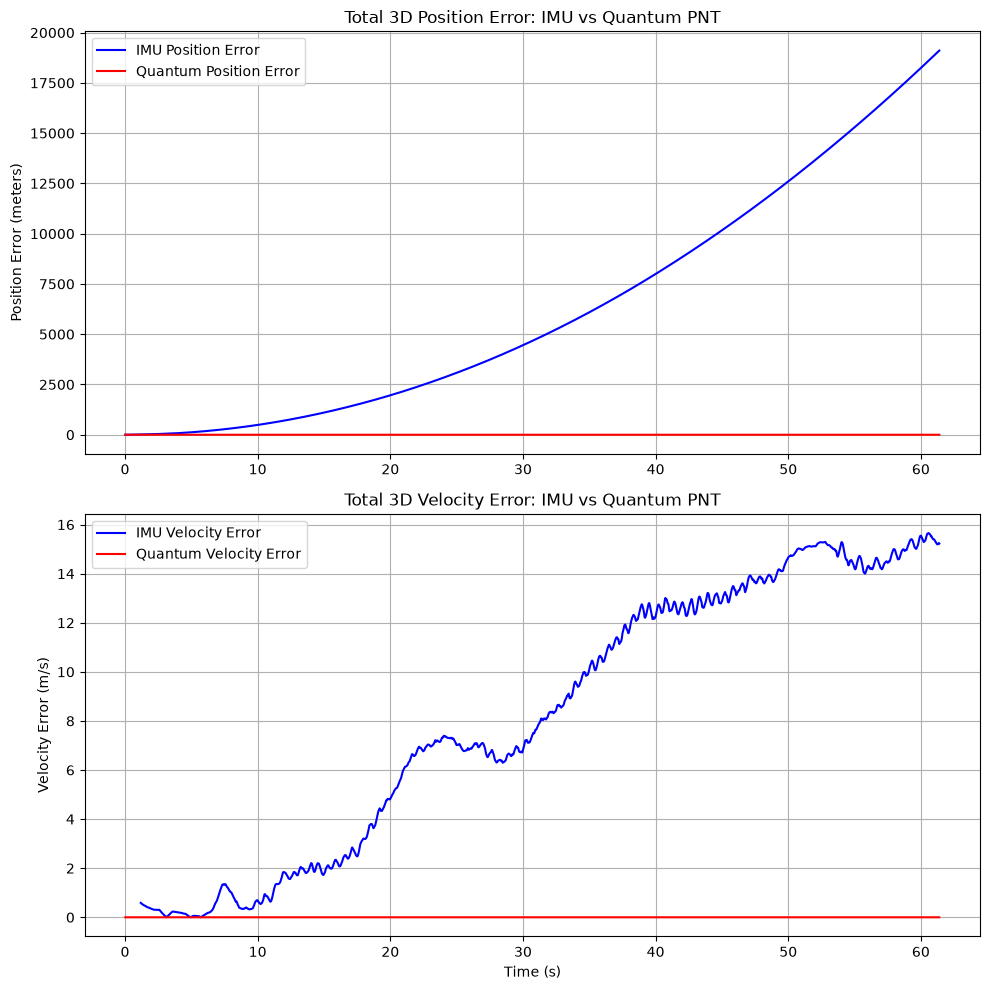

In [14]:
'''visualisation'''

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

ax1.plot(t_acc, imu_pos_err, label='IMU Position Error', color='blue')
ax1.plot(t_acc, quantum_err, label='Quantum Position Error', color='red')
ax1.set_title('Total 3D Position Error: IMU vs Quantum PNT')
ax1.set_ylabel('Position Error (meters)')
ax1.legend()
ax1.grid(True)

ax2.plot(t_acc, imu_vel_err, label='IMU Velocity Error', color='blue')
ax2.plot(t_acc, quantum_err, label='Quantum Velocity Error', color='red')
ax2.set_title('Total 3D Velocity Error: IMU vs Quantum PNT')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Velocity Error (m/s)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()